## Machine Learning Project Checklist

1. Frame the problem and look at the big picture.
2. Get the data.
3. Explore the data to gain insights.
4. Prepare the data to better expose the underlying data patterns to Machine Learning algorithms.
5. Explore many different models and shortlist the best ones.
6. Fine-tune your models and combine them into a great solution.
7. Present your solution.
8. Launch, monitor, and maintain your system.

<!-- Frame the problem and look at the big picture. -->

## Abalone Prediction

<!-- In portuguese, same as README.md at professor's repo -->

A base consiste de informações de um molusco chamado Abalone, e o objetivo do classificador é identificar o tipo do exemplar (entre as classes I, II e III) utilizando as informações fornecidas e detalhadas a seguir.

### Atributos do dataset:

* Sex: M, F e I (infantil)
* Length: maior medida em mm da concha
* Diameter: diametro em mm perpendicular a medida Length
* Height: altura em mm com a carne dentro da concha
* Whole weight: peso em gramas de toda a abalone
* Shucked weight: peso em gramas da carne
* Viscera weight: peso em gramas das víceras após escorrer
* Shell weight: peso em gramas para a concha após estar seca
* Type: variável de classe (1, 2 ou 3) para o abalone

### Objective 

The main objective of this ML project is to predict the attribute "Type" for the Abalone, based on the other attributes.

### Framing the Problem

The problem can be defined as a supervised classification task, using batch (offline) learning.

### Performance Measure

_TODO: Define the performance metrics_ 

<!-- Describe the dataset here -->

<!-- 2. Get the data -->

## Get the Data

The dataset is available and divided as:

1. `abalone_app.csv`: Dataset for validation at professor's server
2. `abalone_dataset.csv`: Dataset for usage in ML project

In [2]:
import pandas as pd

ABALONE_DATASET_PATH = "../abalone_dataset.csv" # Relative path to the abalone dataset CSV file

def load_abalone_dataset():
    """
    Loads the abalone dataset from the specified CSV file path.

    Returns:
        pandas.DataFrame: A DataFrame containing the abalone dataset.
    """
    try:
        # Read the CSV file into a DataFrame
        abalone_df = pd.read_csv(ABALONE_DATASET_PATH)
        return abalone_df
    except FileNotFoundError:
        print(f"Error: The file at {ABALONE_DATASET_PATH} was not found.")
        return None
    except Exception as e:
        print(f"An error occurred while loading the dataset: {e}")
        return None


In [3]:
abalone_df = load_abalone_dataset()
abalone_df.head()  # Display the first few rows of the dataset

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,type
0,M,0.535,0.420,0.150,0.6995,0.2575,0.1530,0.2400,3
1,I,0.510,0.380,0.115,0.5155,0.2150,0.1135,0.1660,1
2,I,0.185,0.130,0.045,0.0290,0.0120,0.0075,0.0095,1
3,M,0.550,0.450,0.170,0.8100,0.3170,0.1570,0.2200,3
4,I,0.535,0.415,0.150,0.5765,0.3595,0.1350,0.2250,1


In [4]:
abalone_df.info()  # Display information about the dataset, including data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 3132 entries, 0 to 3131
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             3132 non-null   str    
 1   length          3132 non-null   float64
 2   diameter        3132 non-null   float64
 3   height          3132 non-null   float64
 4   whole_weight    3132 non-null   float64
 5   shucked_weight  3132 non-null   float64
 6   viscera_weight  3132 non-null   float64
 7   shell_weight    3132 non-null   float64
 8   type            3132 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 220.3 KB


In [5]:
abalone_df["sex"].value_counts()  # Display the counts of each category in the 'Sex' column

sex
M    1137
I    1042
F     953
Name: count, dtype: int64

In [6]:
abalone_df.describe()  # Display summary statistics for the numerical columns in the dataset

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,type
count,3132.000000,3132.000000,3132.000000,3132.000000,3132.000000,3132.000000,3132.000000,3132.000000
mean,0.521392,0.405865,0.138263,0.818738,0.355398,0.178349,0.235616,1.991379
std,0.120756,0.099600,0.039206,0.489560,0.221473,0.109554,0.139215,0.824561
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.345000,0.110000,0.436375,0.181500,0.090875,0.127500,1.000000
50%,0.540000,0.420000,0.140000,0.787000,0.330500,0.168000,0.225000,2.000000
75%,0.610000,0.480000,0.165000,1.141625,0.497500,0.250125,0.323625,3.000000
max,0.815000,0.650000,0.515000,2.825500,1.488000,0.760000,1.005000,3.000000


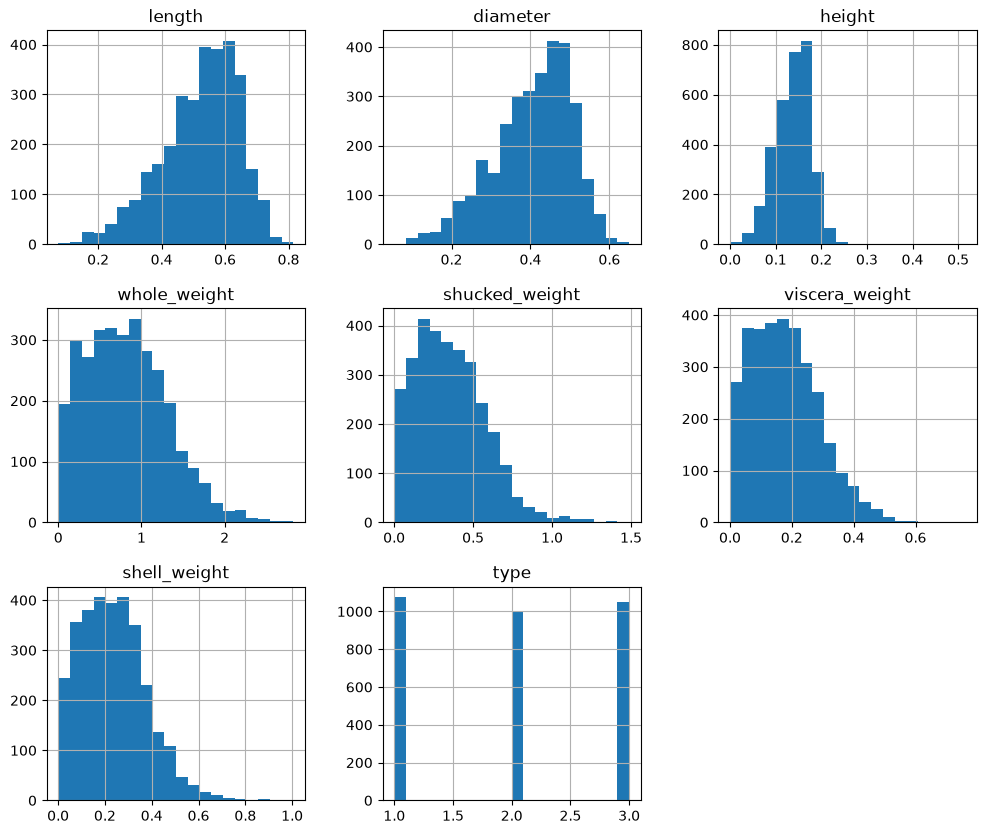

In [7]:
import matplotlib.pyplot as plt

abalone_df.hist(bins=20, figsize=(12, 10))  # Create histograms for each numerical column
plt.show() # Display the histograms

### Data Integrity Assumptions

1. Since all the weight attributes are dependents, we can assume that `whole weight` is always bigger than the others weights individually;
2. The `whole weight` attribute value must be close to the sum of the other weight attributes;    

In [8]:
# Checking assumption 1.

# Exists in the dataset rows that whole_weight is less than the other weights? Let's check it out.

print("Rows where whole_weight is less than shucked_weight:")
display(abalone_df[abalone_df['whole_weight'] < abalone_df['shucked_weight']])

print("Rows where whole_weight is less than viscera_weight:")
display(abalone_df[abalone_df['whole_weight'] < abalone_df['viscera_weight']])

print("Rows where whole_weight is less than shell_weight:")
display(abalone_df[abalone_df['whole_weight'] < abalone_df['shell_weight']])


Rows where whole_weight is less than shucked_weight:


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,type
1209,I,0.355,0.270,0.075,0.2040,0.3045,0.0460,0.0595,1
1424,I,0.475,0.365,0.100,0.1315,0.2025,0.0875,0.1230,1
2046,I,0.310,0.225,0.070,0.1055,0.4350,0.0150,0.0400,1
3033,I,0.275,0.205,0.070,0.1055,0.4950,0.0190,0.0315,1


Rows where whole_weight is less than viscera_weight:


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,type


Rows where whole_weight is less than shell_weight:


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,type
3078,I,0.315,0.23,0.0,0.134,0.0575,0.0285,0.3505,1


Only 5 instances appears to differ from the assumption. We can clean these from the dataset, or just ignore based on the short amount.

In [9]:
rows_with_sum_greater_than_whole = abalone_df[
    (
        abalone_df['shucked_weight']
        + abalone_df['viscera_weight']
        + abalone_df['shell_weight']
    ) > abalone_df['whole_weight']
].copy()

rows_with_sum_greater_than_whole['percentage_difference'] = (
    (
        rows_with_sum_greater_than_whole['shucked_weight']
        + rows_with_sum_greater_than_whole['viscera_weight']
        + rows_with_sum_greater_than_whole['shell_weight']
        - rows_with_sum_greater_than_whole['whole_weight']
    )
    / rows_with_sum_greater_than_whole['whole_weight']
    * 100
)

display(
    rows_with_sum_greater_than_whole[
        ['whole_weight', 'shucked_weight', 'viscera_weight',
         'shell_weight', 'percentage_difference']
    ]
    .sort_values('percentage_difference', ascending=False)
    .round(2)
)

,whole_weight,shucked_weight,viscera_weight,shell_weight,percentage_difference
3033,0.11,0.50,0.02,0.03,417.06
2046,0.11,0.44,0.02,0.04,364.45
3078,0.13,0.06,0.03,0.35,225.75
1424,0.13,0.20,0.09,0.12,214.07
2120,0.13,0.11,0.07,0.08,106.30
...,...,...,...,...,...
2283,0.35,0.16,0.09,0.10,0.14
1662,0.36,0.14,0.10,0.13,0.14
2,0.03,0.01,0.01,0.01,0.00
1681,0.05,0.02,0.02,0.02,0.00


In [10]:
diff = rows_with_sum_greater_than_whole['percentage_difference']

print(f"Number of inconsistent rows: {len(diff)}")
print(f"Mean difference: {diff.mean():.2f}%")
print(f"Median difference: {diff.median():.2f}%")
print(f"Minimum difference: {diff.min():.2f}%")
print(f"Maximum difference: {diff.max():.2f}%")
print(f"75th quantile: {diff.quantile(0.75):.2f}%")

Number of inconsistent rows: 117
Mean difference: 19.18%
Median difference: 3.89%
Minimum difference: 0.00%
Maximum difference: 417.06%
75th quantile: 9.12%


Since the mean difference and median difference are significantly small, we can keep until the 75 quartile, and remove the instances with a big inconsistent measure.

### Basic Cleanup

Before going further on the exploration, we gonna cleanup the data with these basic data integrity checks.

In [11]:
# Basic Cleanup

# Removing the rows where:
# - whole_weight is less than shucked_weight
# - whole_weight is less than viscera_weight
# - whole_weight is less than shell_weight
# - whole_weight is less (by a certain percentage) than the sum of shucked_weight, viscera_weight, and shell_weight

def clean_abalone_dataset(df, percentage_threshold=10):
    """
    Cleans the abalone dataset by removing inconsistent rows based on weight assumptions.

    Args:
        df (pandas.DataFrame): The abalone dataset DataFrame.
        percentage_threshold (float): The threshold for percentage difference to consider a row inconsistent.

    Returns:
        pandas.DataFrame: The cleaned abalone dataset.
    """
    # Remove rows where whole_weight is less than any of the other weights
    df_cleaned = df[
        (df['whole_weight'] >= df['shucked_weight']) &
        (df['whole_weight'] >= df['viscera_weight']) &
        (df['whole_weight'] >= df['shell_weight'])
    ].copy()

    # Calculate the sum of the other weights
    df_cleaned['sum_of_weights'] = (
        df_cleaned['shucked_weight'] +
        df_cleaned['viscera_weight'] +
        df_cleaned['shell_weight']
    )

    # Calculate the percentage difference
    df_cleaned['percentage_difference'] = (
        (df_cleaned['sum_of_weights'] - df_cleaned['whole_weight']) /
        df_cleaned['whole_weight'] * 100
    )

    # Remove rows where the percentage difference exceeds the threshold
    df_final = df_cleaned[df_cleaned['percentage_difference'] <= percentage_threshold].copy()

    # Drop the temporary columns used for calculations
    df_final.drop(columns=['sum_of_weights', 'percentage_difference'], inplace=True)

    return df_final

In [12]:
# Checking the assumptions again after cleaning the dataset

cleaned_abalone_df = clean_abalone_dataset(abalone_df)

In [13]:
# Checking assumption 1.

# Exists in the dataset rows that whole_weight is less than the other weights? Let's check it out.

print("Rows where whole_weight is less than shucked_weight:")
display(cleaned_abalone_df[cleaned_abalone_df['whole_weight'] < cleaned_abalone_df['shucked_weight']])

print("Rows where whole_weight is less than viscera_weight:")
display(cleaned_abalone_df[cleaned_abalone_df['whole_weight'] < cleaned_abalone_df['viscera_weight']])

print("Rows where whole_weight is less than shell_weight:")
display(cleaned_abalone_df[cleaned_abalone_df['whole_weight'] < cleaned_abalone_df['shell_weight']])

Rows where whole_weight is less than shucked_weight:


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,type


Rows where whole_weight is less than viscera_weight:


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,type


Rows where whole_weight is less than shell_weight:


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,type


In [14]:
rows_with_sum_greater_than_whole = cleaned_abalone_df[
    (
        cleaned_abalone_df['shucked_weight']
        + cleaned_abalone_df['viscera_weight']
        + cleaned_abalone_df['shell_weight']
    ) > cleaned_abalone_df['whole_weight']
].copy()

rows_with_sum_greater_than_whole['percentage_difference'] = (
    (
        rows_with_sum_greater_than_whole['shucked_weight']
        + rows_with_sum_greater_than_whole['viscera_weight']
        + rows_with_sum_greater_than_whole['shell_weight']
        - rows_with_sum_greater_than_whole['whole_weight']
    )
    / rows_with_sum_greater_than_whole['whole_weight']
    * 100
)

display(
    rows_with_sum_greater_than_whole[
        ['whole_weight', 'shucked_weight', 'viscera_weight',
         'shell_weight', 'percentage_difference']
    ]
    .sort_values('percentage_difference', ascending=False)
    .round(2)
)

,whole_weight,shucked_weight,viscera_weight,shell_weight,percentage_difference
1334,0.43,0.20,0.13,0.14,9.12
784,0.11,0.04,0.04,0.04,9.00
2843,0.10,0.04,0.03,0.04,8.59
2538,0.19,0.08,0.06,0.07,7.81
2833,1.21,0.71,0.27,0.32,7.56
...,...,...,...,...,...
2283,0.35,0.16,0.09,0.10,0.14
1662,0.36,0.14,0.10,0.13,0.14
2,0.03,0.01,0.01,0.01,0.00
1681,0.05,0.02,0.02,0.02,0.00


### Creating a Test Set

In [15]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(cleaned_abalone_df, test_size=0.2, random_state=42, stratify=cleaned_abalone_df['type'])

# Check the distribution of the target variable (type) in both the training and test sets to ensure they are similar.
print("Original")
print(cleaned_abalone_df['type'].value_counts(normalize=True))

print("\nTrain")
print(train_set['type'].value_counts(normalize=True))

print("\nTest")
print(test_set['type'].value_counts(normalize=True))

Original
type
1    0.340316
3    0.337738
2    0.321947
Name: proportion, dtype: float64

Train
type
1    0.340451
3    0.337631
2    0.321918
Name: proportion, dtype: float64

Test
type
1    0.339775
3    0.338164
2    0.322061
Name: proportion, dtype: float64


<!-- 3. Explore the data -->

## Explore the data

In [16]:
abalone_df = train_set.copy()

### Visualizing the abalone shapes

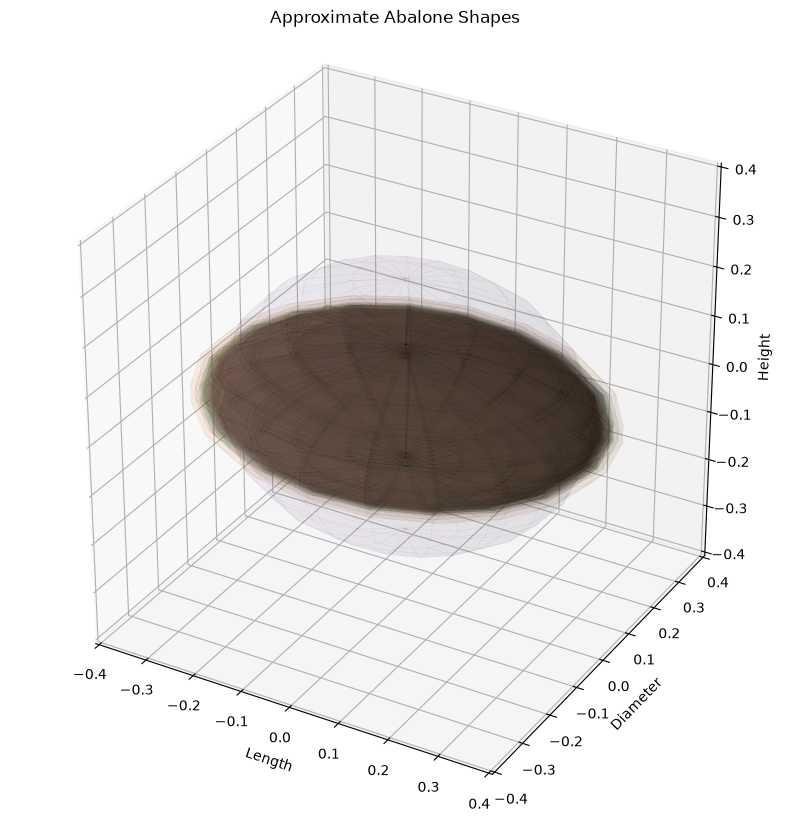

In [17]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

# Parametric coordinates for a sphere
u = np.linspace(0, 2 * np.pi, 20)
v = np.linspace(0, np.pi, 12)

for _, row in abalone_df.iterrows():
    a = row["length"] / 2
    b = row["diameter"] / 2
    c = row["height"] / 2

    x = a * np.outer(np.cos(u), np.sin(v))
    y = b * np.outer(np.sin(u), np.sin(v))
    z = c * np.outer(np.ones_like(u), np.cos(v))

    ax.plot_surface(
        x,
        y,
        z,
        edgecolor="k",
        alpha=0.05,
        linewidth=0.01
    )

ax.set_xlabel("Length")
ax.set_ylabel("Diameter")
ax.set_zlabel("Height")

ax.set_title("Approximate Abalone Shapes")

max_radius = max(
    abalone_df["length"].max() / 2,
    abalone_df["diameter"].max() / 2,
    abalone_df["height"].max() / 2
)

ax.set_xlim([-max_radius, max_radius])
ax.set_ylim([-max_radius, max_radius])
ax.set_zlim([-max_radius, max_radius])

ax.set_box_aspect((1, 1, 1))

plt.show()

Based on this visualization, is fair to assume that dimensions and proportion of dimensions are similar for the most.

### Looking for correlations

,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight
length,1.000000,0.986768,0.887317,0.924543,0.895994,0.902968,0.895573
diameter,0.986768,1.000000,0.895272,0.925183,0.892204,0.899572,0.903996
height,0.887317,0.895272,1.000000,0.881317,0.830889,0.857590,0.881133
whole_weight,0.924543,0.925183,0.881317,1.000000,0.970754,0.967907,0.953972
shucked_weight,0.895994,0.892204,0.830889,0.970754,1.000000,0.932008,0.879318
viscera_weight,0.902968,0.899572,0.857590,0.967907,0.932008,1.000000,0.905623
shell_weight,0.895573,0.903996,0.881133,0.953972,0.879318,0.905623,1.000000


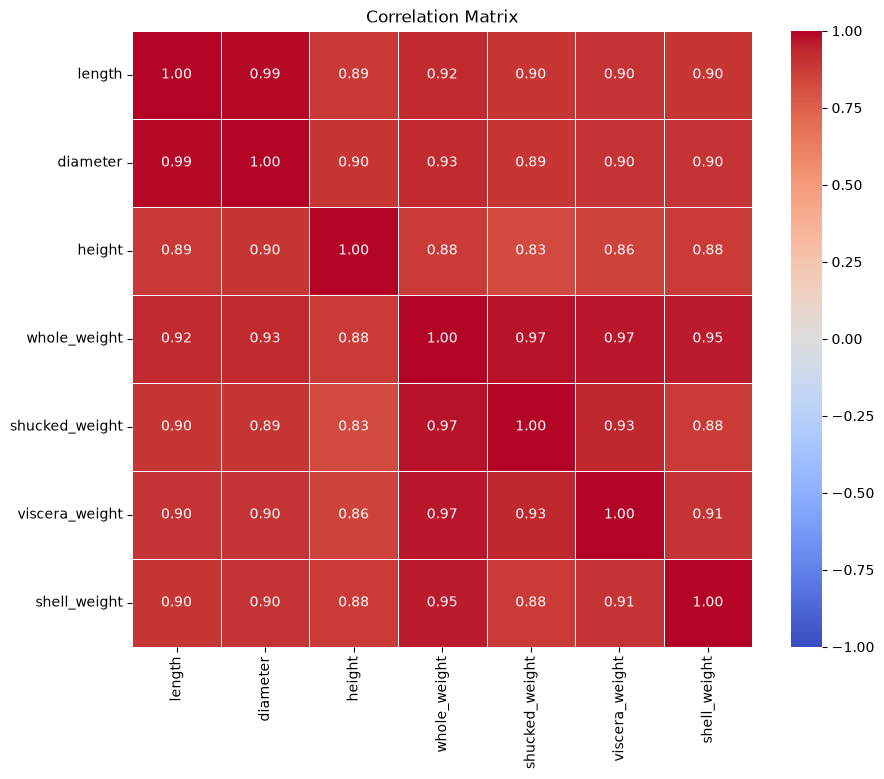

In [18]:
import seaborn as sns

# Correlation matrix to understand relationships between numerical features

num_only_df = abalone_df.select_dtypes(include=[np.float64])  # Select only numerical columns

corr_matrix = num_only_df.corr()
display(corr_matrix)  # Display the correlation matrix

# Display as a heatmap for better visualization

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

The numerical attributes exhibit strong positive correlations. In particular, length and diameter are almost perfectly correlated (r = 0.99), while whole weight is strongly correlated with the component weights (r = 0.95 – 0.97). This suggests substantial redundancy among the physical measurements and indicates that the features largely capture a common underlying factor related to overall abalone size.

<!--4. Prepare the data to better expose the underlying data patterns to Machine Learning algorithms.-->

# Preparing the data



In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = abalone_df.drop(columns=['type'])  # Features
y = abalone_df['type']  # Target variable

num_attributes = ['length', 'diameter', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight']
cat_attributes = ['sex']  

full_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_attributes),  # Scale numerical attributes
        ('cat', OneHotEncoder(), cat_attributes)  # One-hot encode categorical attributes
    ]
)

X = full_preprocessor.fit_transform(X)  # Apply the transformations to the features

# Select and Training Models

## Dummy Classifier

TODO: Add a explaining text about this

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dummy_classifier = DummyClassifier(strategy="most_frequent")  # Create a dummy classifier that predicts the most frequent class
dummy_classifier.fit(X, y) 

predictions = dummy_classifier.predict(X)  # Make predictions on the preprocessed features

accuracy = accuracy_score(y, predictions)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y, predictions))

print("Confusion Matrix:")
print(confusion_matrix(y, predictions))

Accuracy: 0.3405
Classification Report:
              precision    recall  f1-score   support

           1       0.34      1.00      0.51       845
           2       0.00      0.00      0.00       799
           3       0.00      0.00      0.00       838

    accuracy                           0.34      2482
   macro avg       0.11      0.33      0.17      2482
weighted avg       0.12      0.34      0.17      2482

Confusion Matrix:
[[845   0   0]
 [799   0   0]
 [838   0   0]]


/Users/ricardo/repos/mlclass/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ricardo/repos/mlclass/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ricardo/repos/mlclass/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

## Logistic Regression

In [21]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X, y)  # Fit the logistic regression model to the preprocessed features and target variable

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [22]:
some_data = X[0:5]  # Select the first 5 samples for prediction
some_labels = y[0:5]  # Select the corresponding labels for the first 5 samples

some_predictions = log_reg.predict(some_data)  # Make predictions on the preprocessed samples

print("Predictions:", some_predictions)
print("Actual labels:", list(some_labels))

Predictions: [2 1 3 1 3]
Actual labels: [3, 1, 3, 1, 3]


In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

predictions = log_reg.predict(X)  # Make predictions on the entire dataset

accuracy = accuracy_score(y, predictions)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y, predictions))

print("Confusion Matrix:")
print(confusion_matrix(y, predictions))

Accuracy: 0.6591
Classification Report:
              precision    recall  f1-score   support

           1       0.73      0.76      0.75       845
           2       0.53      0.55      0.54       799
           3       0.72      0.66      0.68       838

    accuracy                           0.66      2482
   macro avg       0.66      0.66      0.66      2482
weighted avg       0.66      0.66      0.66      2482

Confusion Matrix:
[[646 168  31]
 [173 441 185]
 [ 61 228 549]]


In [24]:
# Using cross-validation to evaluate the models

from sklearn.model_selection import cross_val_score

scores = cross_val_score(log_reg, X, y, scoring='accuracy', cv=10)  # Perform 10-fold cross-validation

print(f"Cross-validation scores: {scores}")
print(f"Mean cross-validation score: {scores.mean():.4f}")

Cross-validation scores: [0.63052209 0.68674699 0.63306452 0.64112903 0.66935484 0.66129032
 0.64919355 0.6733871  0.66129032 0.66532258]
Mean cross-validation score: 0.6571


## K-Nearest Neighbors (KNN)

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X, y)  # Fit the k-nearest neighbors classifier to the preprocessed features and target variable

predictions = knn.predict(X)  # Make predictions on the entire dataset

accuracy = accuracy_score(y, predictions)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y, predictions))

print("Confusion Matrix:")
print(confusion_matrix(y, predictions))

Accuracy: 0.7305
Classification Report:
              precision    recall  f1-score   support

           1       0.78      0.84      0.81       845
           2       0.62      0.67      0.65       799
           3       0.79      0.68      0.73       838

    accuracy                           0.73      2482
   macro avg       0.73      0.73      0.73      2482
weighted avg       0.73      0.73      0.73      2482

Confusion Matrix:
[[710 113  22]
 [135 536 128]
 [ 62 209 567]]


In [26]:
# Using cross-validation to evaluate the models

scores = cross_val_score(knn, X, y, scoring='accuracy', cv=10)  # Perform 10-fold cross-validation

print(f"Cross-validation scores: {scores}")
print(f"Mean cross-validation score: {scores.mean():.4f}")

Cross-validation scores: [0.53413655 0.59437751 0.58870968 0.58064516 0.60080645 0.62903226
 0.61693548 0.64112903 0.59677419 0.60080645]
Mean cross-validation score: 0.5983


## Decision Tree

In [27]:
from sklearn.tree import DecisionTreeClassifier

tree_clf = DecisionTreeClassifier(random_state=42)  # Create a decision tree classifier with a fixed random state for reproducibility
tree_clf.fit(X, y)  # Fit the decision tree classifier to the preprocessed features and target variable

predictions = tree_clf.predict(X)  # Make predictions on the entire dataset

accuracy = accuracy_score(y, predictions)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y, predictions))

print("Confusion Matrix:")
print(confusion_matrix(y, predictions))

Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       845
           2       1.00      1.00      1.00       799
           3       1.00      1.00      1.00       838

    accuracy                           1.00      2482
   macro avg       1.00      1.00      1.00      2482
weighted avg       1.00      1.00      1.00      2482

Confusion Matrix:
[[845   0   0]
 [  0 799   0]
 [  0   0 838]]


In [28]:
# Using cross-validation to evaluate the Decision Tree Classifier

from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_clf, X, y, scoring='accuracy', cv=10)  # Perform 10-fold cross-validation

print(f"Cross-validation scores: {scores}")
print(f"Mean cross-validation score: {scores.mean():.4f}")

Cross-validation scores: [0.5502008  0.57028112 0.54032258 0.5483871  0.55645161 0.59677419
 0.57258065 0.56854839 0.56048387 0.58064516]
Mean cross-validation score: 0.5645


## Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)  # Create a random forest classifier with 100 trees and a fixed random state for reproducibility
rf_clf.fit(X, y)  # Fit the random forest classifier to the preprocessed features and target variable

predictions = rf_clf.predict(X)  # Make predictions on the entire dataset

accuracy = accuracy_score(y, predictions)
print(f"Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(y, predictions))

print("Confusion Matrix:")
print(confusion_matrix(y, predictions))

Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       845
           2       1.00      1.00      1.00       799
           3       1.00      1.00      1.00       838

    accuracy                           1.00      2482
   macro avg       1.00      1.00      1.00      2482
weighted avg       1.00      1.00      1.00      2482

Confusion Matrix:
[[845   0   0]
 [  0 799   0]
 [  0   0 838]]


In [30]:
# Using cross-validation to evaluate the models

from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_clf, X, y, scoring='accuracy', cv=10)  # Perform 10-fold cross-validation

print(f"Cross-validation scores: {scores}")
print(f"Mean cross-validation score: {scores.mean():.4f}")

Cross-validation scores: [0.6184739  0.64257028 0.60483871 0.65322581 0.66129032 0.66935484
 0.64516129 0.68548387 0.66532258 0.65322581]
Mean cross-validation score: 0.6499


## Fine-tuning the model

In [32]:
# Lets try fine-tuning the hyperparameters of the Random Forest Classifier using GridSearchCV

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = [
    {
        'n_estimators': [3, 10, 30, 50, 100],    # Number of trees in the forest
        'max_features': [2, 4, 6, 8, 10, 12]    # Number of features to consider when looking for the best split
    },
    {
        'bootstrap': [False],   # Whether bootstrap samples are used when building trees
        'n_estimators': [3, 10, 30, 50, 100],    # Number of trees in the forest
        'max_features': [2, 3, 4, 5, 6]    # Number of features to consider when looking for the best split
    }
]

forest_clf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(forest_clf, param_grid, cv=5, scoring='accuracy', return_train_score=True)

grid_search.fit(X, y)  # Perform grid search to find the best hyperparameters for the random forest classifier

print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best hyperparameters: {'max_features': 6, 'n_estimators': 100}
Best cross-validation score: 0.6583565911598624


In [34]:
# Lets try fine-tuning the hyperparameters of the Random Forest Classifier using RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    "n_estimators": [50, 100, 200, 300, 500],
    "max_features": ["sqrt", "log2", None, 2, 4, 6, 8],
    "max_depth": [None, 10, 20, 30, 40, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}

forest_clf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    forest_clf,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

random_search.fit(X, y)

print("Best hyperparameters:", random_search.best_params_)
print("Best cross-validation score:", random_search.best_score_)

Best hyperparameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 6, 'max_depth': None, 'bootstrap': True}
Best cross-validation score: 0.6627872071136497


In [36]:
feature_importances = random_search.best_estimator_.feature_importances_
feature_names = full_preprocessor.get_feature_names_out()

for name, score in sorted(
    zip(feature_names, feature_importances),
    key=lambda item: item[1],
    reverse=True
):
    print(f"{name}: {score:.4f}")

num__shell_weight: 0.2827
num__shucked_weight: 0.1417
num__whole_weight: 0.1253
num__height: 0.1202
num__viscera_weight: 0.1176
num__diameter: 0.0810
num__length: 0.0781
cat__sex_I: 0.0289
cat__sex_F: 0.0122
cat__sex_M: 0.0121


In [41]:
log_reg_param_grid = [
    {
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"],
        "max_iter": [1000]
    },
    {
        "solver": ["liblinear"],
        "penalty": ["l1", "l2"],
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "class_weight": [None, "balanced"],
        "max_iter": [1000]
    }
]

log_reg_grid_search = GridSearchCV(
    LogisticRegression(),
    param_grid=log_reg_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

log_reg_grid_search.fit(X, y)

print("Best hyperparameters:")
print(log_reg_grid_search.best_params_)

print(f"\nBest cross-validation accuracy: "
      f"{log_reg_grid_search.best_score_:.4f}")

best_log_reg = log_reg_grid_search.best_estimator_

test_predictions = best_log_reg.predict(X_test)

print(f"\nTest accuracy: {accuracy_score(y_test, test_predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, test_predictions))

print("Confusion Matrix:")
print(confusion_matrix(y_test, test_predictions))

/Users/ricardo/repos/mlclass/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ricardo/repos/mlclass/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/ricardo/rep

Best hyperparameters:
{'C': 100, 'class_weight': None, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}

Best cross-validation accuracy: 0.6596

Test accuracy: 0.6538

Classification Report:
              precision    recall  f1-score   support

           1       0.72      0.80      0.76       211
           2       0.54      0.51      0.52       200
           3       0.68      0.65      0.67       210

    accuracy                           0.65       621
   macro avg       0.65      0.65      0.65       621
weighted avg       0.65      0.65      0.65       621

Confusion Matrix:
[[168  35   8]
 [ 43 101  56]
 [ 21  52 137]]
